
Overall Similarity Statistics:
Mean of Min Similarities: 0.055
Mean of Max Similarities: 0.460
Mean of Mean Similarities: 0.182

✅ Tanimoto similarity results saved to Excel.


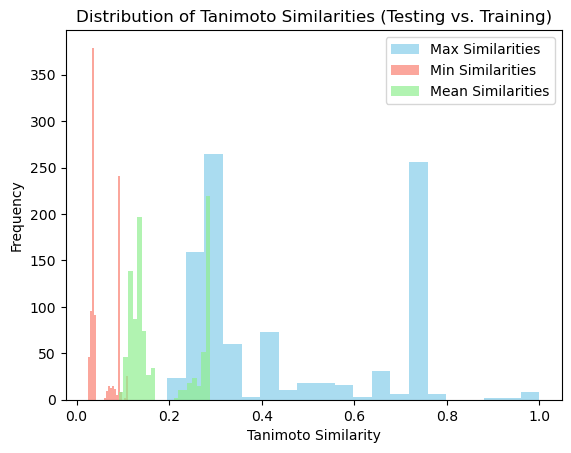

In [4]:
# Import required libraries
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 1. Load Data From Excel Files
# ================================
property = 'Activity'

# File paths
smiles_file_training = rf"C:\Users\grvkr\Box\Gaurav Kumar\Projects\SAR_NM\Data\Data_Combined\{property}\InVitro_SMILES_Training.xlsx"
smiles_file_testing = rf"C:\Users\grvkr\Box\Gaurav Kumar\Projects\SAR_NM\Data\Data_Combined\{property}\InVitro_SMILES_Testing.xlsx"
smiles_sheet_name = "SMILES"

# Load SMILES data into DataFrames
smiles_df_training = pd.read_excel(smiles_file_training, sheet_name=smiles_sheet_name)
smiles_df_testing = pd.read_excel(smiles_file_testing, sheet_name=smiles_sheet_name)

# ================================
# 2. Generate Morgan Fingerprints
# ================================
def smiles_to_fp(smiles, radius=2, nBits=2048):
    """Convert a SMILES string to a Morgan fingerprint."""
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    else:
        return None

# Extract SMILES from the first column
smiles_training = smiles_df_training.iloc[:, 0].dropna().tolist()
smiles_testing = smiles_df_testing.iloc[:, 0].dropna().tolist()

# Generate fingerprints for training and testing sets
fps_training = [smiles_to_fp(sm) for sm in smiles_training if smiles_to_fp(sm) is not None]
fps_testing = [smiles_to_fp(sm) for sm in smiles_testing if smiles_to_fp(sm) is not None]

# ================================
# 3. Calculate Tanimoto Similarities (Min, Max, Mean)
# ================================
def calculate_tanimoto_similarity(fps_training, fps_testing):
    """Calculate min, max, and mean Tanimoto similarity between training and testing molecules."""
    min_similarities = []
    max_similarities = []
    mean_similarities = []
    
    for fp_test in fps_testing:
        # Calculate similarities with all training fingerprints
        similarities = [TanimotoSimilarity(fp_test, fp_train) for fp_train in fps_training]
        
        # Store min, max, and mean similarities
        min_similarities.append(np.min(similarities))
        max_similarities.append(np.max(similarities))
        mean_similarities.append(np.mean(similarities))
        
    return min_similarities, max_similarities, mean_similarities

# Calculate similarities
min_similarities, max_similarities, mean_similarities = calculate_tanimoto_similarity(fps_training, fps_testing)

# ================================
# 4. Display Overall Statistics
# ================================
print("\nOverall Similarity Statistics:")
print(f"Mean of Min Similarities: {np.mean(min_similarities):.3f}")
print(f"Mean of Max Similarities: {np.mean(max_similarities):.3f}")
print(f"Mean of Mean Similarities: {np.mean(mean_similarities):.3f}")

# ================================
# 5. Save Results to Excel File
# ================================
results_df = pd.DataFrame({
    'SMILES_Testing': smiles_testing,
    'Min_Tanimoto_Similarity': min_similarities,
    'Max_Tanimoto_Similarity': max_similarities,
    'Mean_Tanimoto_Similarity': mean_similarities
})

output_file = r'C:\Users\grvkr\Box\Gaurav Kumar\Projects\SAR_NM\Codes\ML_Framework\Data_Combined\Tanimoto_Similarity_Results.xlsx'
results_df.to_excel(output_file, index=False)
print("\n✅ Tanimoto similarity results saved to Excel.")

# ================================
# 6. Optional: Visualize Results
# ================================
plt.hist(max_similarities, bins=20, alpha=0.7, label='Max Similarities', color='skyblue')
plt.hist(min_similarities, bins=20, alpha=0.7, label='Min Similarities', color='salmon')
plt.hist(mean_similarities, bins=20, alpha=0.7, label='Mean Similarities', color='lightgreen')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Tanimoto Similarities (Testing vs. Training)')
plt.legend()
plt.show()
